# Advanced RPG systems
* lesson 32 already built a minimal but complete RPG capstone: one player, a couple of simple items, and one turn-based battle against one enemy - genuinely a whole tiny game, but a "real" RPG usually needs quite a bit more depth than that
* this lesson adds a bunch of the systems that basically every full-size RPG has: leveling up / XP, status effects (poison, temporary stat buffs), a multi-character PARTY (not just one lone hero) with mid-battle switching, a shop/economy with gold, save/load persistence so a playthrough survives closing the game, and a world made of multiple CONNECTED maps you can walk between
* just like every lesson in this game-dev arc, this notebook is fully self-contained - we rebuild small versions of lesson 31/32's world/player/battle ideas ourselves in our own words, we dont import anything from those other notebooks

## setup (recap lesson 27)
* same headless pygame trick used by every lesson in this whole game-dev arc: we tell SDL (the library pygame wraps) to render off-screen using its "dummy" video/audio driver, since this notebook runs on a server with no real screen attached
* those two environment variables MUST be set before `import pygame` happens at all - go back to lesson 27 for the full explanation if this is new to you
* we also fix the random seed right away, since we use randomness for a little bit of battle damage variance later - a fixed seed means everyone running this notebook gets the exact same, fully reproducible outcome

In [1]:
import os

# these two lines MUST run before "import pygame" - same headless setup as every lesson in this arc (recap lesson 27)
os.environ["SDL_VIDEODRIVER"] = "dummy"   # render off-screen instead of opening a real window
os.environ["SDL_AUDIODRIVER"] = "dummy"   # no real sound device needed for this lesson

import pygame
import numpy as np
import matplotlib.pyplot as plt
import random    # for a little bit of reproducible damage variance in battles
import json      # our save/load format of choice for this lesson (recap lesson 05) - plain, human-readable, no extra dependency
import copy      # we use copy.copy() to clone Item objects so the shop never hands out a shared/aliased object
from dataclasses import dataclass, field  # recap lesson 10 - perfect for small, mostly-data records like StatusEffect/Item

pygame.init()       # boots up pygame's subsystems (video etc)
pygame.font.init()  # font rendering is its own subsystem, we need it for the battle screen and world snapshots

random.seed(42)  # fixed seed - every random.randint() call below becomes fully reproducible, run after run


def show_surface(surface, title=None, figsize=(5, 4)):
    """Render a pygame Surface inline in the notebook (recap lesson 27)."""
    # pygame stores pixels as (width, height, channels), matplotlib wants (height, width, channels) - swap axes
    pixel_array = pygame.surfarray.array3d(surface).swapaxes(0, 1)
    plt.figure(figsize=figsize)
    plt.imshow(pixel_array)
    plt.axis("off")  # a game screenshot doesnt need axis ticks/labels
    if title:
        plt.title(title)
    plt.show()


FONT = pygame.font.SysFont(None, 18)   # a small built-in font, used everywhere below (hp numbers, labels, messages)
FONT_SMALL = pygame.font.SysFont(None, 14)  # an even smaller font, for cramming status-effect labels into tight spaces

print("pygame ready, lesson 35 setup complete - lets build some deeper RPG systems")

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


pygame ready, lesson 35 setup complete - lets build some deeper RPG systems


## leveling and XP (recap `@dataclass`, lesson 10, and inheritance, lesson 08)
* every fighting character in our RPG (party members AND enemies) shares the same basic stat block, so we put it once in a `Character` base class, exactly like lesson 32 did
* NEW compared to lesson 32: every `Character` now also tracks `level` and `xp` - defeating an enemy grants XP, and once you cross a threshold you level up, which bumps `max_hp`/`attack`/`defense` and fully heals you (a very standard RPG trope)
* we keep the level-up MATH dead simple on purpose: `xp_needed_for_next_level = level * 30`, and each level-up adds `+5 max_hp`, `+2 attack`, `+1 defense` - feel free to tune this yourself, the important part is the PATTERN (accumulate xp -> check threshold -> apply a permanent stat boost) which is genuinely how most RPGs do it, just with fancier curves

In [2]:
@dataclass
class StatusEffect:
    """A temporary effect sitting on a Character - just data, all the actual behaviour lives in Character itself.
    `potency` means different things depending on `name`: damage-per-turn for poison, the stat bonus for a buff."""
    name: str             # "poison" or "attack_buff" in this lesson - see Character.tick_status_effects() below
    remaining_turns: int  # how many more times this effect still triggers before it wears off
    potency: int          # poison damage per turn, OR the attack bonus amount for a buff


class Character:
    """Shared stats + leveling + status effects for anything that can fight in our RPG (party members AND enemies)."""

    def __init__(self, name: str, hp: int, attack: int, defense: int, level: int = 1):
        self.name = name
        self.level = level
        self.xp = 0            # xp accumulated towards the NEXT level, resets (partially) on every level-up
        self.max_hp = hp       # kept separately from hp so we can display "12/20" style hp bars
        self.hp = hp           # current hp starts out full
        self.attack = attack
        self.defense = defense
        self.status_effects: list[StatusEffect] = []  # empty at first - filled via add_status_effect() during battle

    @property
    def is_alive(self) -> bool:
        return self.hp > 0  # a computed property instead of a manually tracked boolean, recap lesson 07

    @property
    def xp_to_next_level(self) -> int:
        """How much MORE xp is needed to hit the next level - our deliberately simple curve, level * 30."""
        return self.level * 30

    def take_damage(self, amount: int) -> None:
        self.hp = max(0, self.hp - amount)  # never let hp go negative, that would look silly on a health bar

    def heal(self, amount: int) -> int:
        """Heal up to `amount`, clamped so we never overheal past max_hp. Returns how much was ACTUALLY healed."""
        healed = min(amount, self.max_hp - self.hp)  # cant heal more than the missing hp
        self.hp += healed
        return healed

    def level_up(self) -> str:
        """Apply one level-up: bump every stat a little, and fully heal (a classic RPG "level up" reward)."""
        self.level += 1
        self.max_hp += 5   # tougher
        self.attack += 2   # hits harder
        self.defense += 1  # shrugs off more damage
        self.hp = self.max_hp  # level-ups fully restore hp in most RPGs, so we do the same here
        return f"{self.name} leveled up! now level {self.level} (HP {self.max_hp}, ATK {self.attack}, DEF {self.defense})"

    def gain_xp(self, amount: int) -> list:
        """Add xp, and keep leveling up for as long as we have enough banked (handles a HUGE xp reward too)."""
        log = [f"{self.name} gains {amount} XP!"]
        self.xp += amount
        while self.xp >= self.xp_to_next_level:      # a while loop (not "if"!) in case one reward crosses 2+ levels
            self.xp -= self.xp_to_next_level           # spend the xp needed for this level, carry the remainder over
            log.append(self.level_up())
        return log

    def add_status_effect(self, effect: StatusEffect) -> str:
        """Attach a new status effect. If the SAME effect is already active we just REFRESH its duration instead
        of stacking a second copy - stacking would make repeated poison bites deal double (or more!) damage every
        turn, which isnt how most RPGs handle it. Buffs apply their stat change immediately, poison just waits to tick."""
        existing = next((e for e in self.status_effects if e.name == effect.name), None)
        if existing is not None:
            existing.remaining_turns = effect.remaining_turns  # just refresh the duration, dont add a second copy
            return f"{self.name}'s {effect.name} is refreshed to {effect.remaining_turns} turns!"
        self.status_effects.append(effect)
        if effect.name == "attack_buff":
            self.attack += effect.potency  # applied ONCE, right away - tick_status_effects() reverts it when it expires
            return f"{self.name}'s attack rises by {effect.potency} for {effect.remaining_turns} turns!"
        return f"{self.name} is afflicted with {effect.name} for {effect.remaining_turns} turns!"

    def tick_status_effects(self) -> list:
        """Process every active status effect for ONE turn - call this once per turn for whoever is acting.
        Poison deals its damage now; every effect's `remaining_turns` counts down; expired buffs get reverted."""
        log = []
        still_active = []  # effects that survive this tick, rebuilt fresh so we can safely remove expired ones
        for effect in self.status_effects:
            if effect.name == "poison":
                self.take_damage(effect.potency)  # poison damage completely ignores defense, on purpose
                log.append(f"{self.name} takes {effect.potency} poison damage! HP: {self.hp}/{self.max_hp}")
            effect.remaining_turns -= 1
            if effect.remaining_turns > 0:
                still_active.append(effect)  # keep it around, it still has turns left
            elif effect.name == "attack_buff":
                self.attack -= effect.potency  # the buff is over - revert the exact amount we added in add_status_effect
                log.append(f"{self.name}'s attack buff wore off (back to {self.attack})")
        self.status_effects = still_active
        return log

    def __str__(self) -> str:
        return f"{self.name} (Lv{self.level}, HP {self.hp}/{self.max_hp}, ATK {self.attack}, DEF {self.defense}, XP {self.xp}/{self.xp_to_next_level})"


# a quick standalone smoke test of leveling, completely separate from the real party/battle further down
demo_hero = Character("Demo Hero", hp=20, attack=5, defense=2)
print("before:", demo_hero)
for line in demo_hero.gain_xp(65):  # 65 xp: enough to level up TWICE from level 1 (needs 30, then 60 cumulative... lets see)
    print(" ", line)
print("after: ", demo_hero)

before: Demo Hero (Lv1, HP 20/20, ATK 5, DEF 2, XP 0/30)
  Demo Hero gains 65 XP!
  Demo Hero leveled up! now level 2 (HP 25, ATK 7, DEF 3)
after:  Demo Hero (Lv2, HP 25/25, ATK 7, DEF 3, XP 35/60)


## a multi-member Party (instead of lesson 32's single Player)
* lesson 32 had exactly ONE `Player`. a "real" RPG almost always gives you a whole PARTY of characters, but only lets ONE of them fight at a time in battle - the "active" member - with the ability to SWITCH which one is active, a genuinely common mechanic (think Pokemon's "switch pokemon", or any RPG with a bench)
* `PartyMember` is just a `Character` with a `role` label for flavor - all the real behaviour is already sitting in `Character` above, this is a nice small bit of inheritance reuse
* the `Party` class owns the list of members, which one is currently `active`, the party's shared `gold`, and a shared `inventory` (recap `Item`/`Inventory` from lesson 32 - here the whole party shares one bag instead of each character having their own)

In [3]:
@dataclass
class Item:
    """A single item, shared bag style - just data, recap dataclass from lesson 32/10. `price` matters for the shop below."""
    name: str
    item_type: str          # "potion" (heals then consumed), "buff" (temp attack buff then consumed), "weapon" (permanent, kept)
    heal_amount: int = 0     # for potions
    attack_bonus: int = 0    # for buffs (temporary) AND weapons (permanent) - see Party.use_item() below
    buff_duration: int = 0   # how many turns a "buff" item's effect lasts (irrelevant for potions/weapons)
    price: int = 0           # gold cost in the shop - 0 for items that were never meant to be bought (found/given items)


class PartyMember(Character):
    """A Character that belongs to a Party. Adds nothing behaviourally, just a `role` label - pure inheritance reuse."""

    def __init__(self, name: str, role: str, hp: int, attack: int, defense: int):
        super().__init__(name, hp, attack, defense)  # let Character set up all the shared stat/xp/status-effect stuff
        self.role = role  # just flavor text ("Warrior", "Scout", "Mage", ...), doesnt affect any game logic here


class Party:
    """Holds 2-3 PartyMembers, tracks which one is ACTIVE in battle, and owns the party's shared gold + inventory."""

    def __init__(self, members: list, gold: int = 0):
        self.members = members       # list[PartyMember], in a fixed order
        self.active_index = 0        # index into self.members of whoever is currently fighting
        self.gold = gold             # shared currency, spent at the Shop below
        self.inventory: list = []    # list[Item] - shared bag, ANY member can use anything in it

    @property
    def active(self) -> PartyMember:
        """Whoever is currently fighting - the one and only member that takes turns in battle right now."""
        return self.members[self.active_index]

    def switch_active(self, new_index: int) -> str:
        """Switch which party member is active. Raises ValueError for an invalid switch (recap lesson 06) -
        cant switch to a fainted member, and cant "switch" to the member already fighting."""
        if new_index == self.active_index:
            raise ValueError("that party member is already active")
        if not self.members[new_index].is_alive:
            raise ValueError(f"cant switch to {self.members[new_index].name}, they have fainted!")
        old_name = self.active.name
        self.active_index = new_index
        return f"{old_name} steps back, {self.active.name} steps up to fight!"

    def grant_xp_to_party(self, amount: int) -> list:
        """After a victory, every party member still standing gets the full xp reward (a common RPG choice -
        the alternative, only the active member gains xp, is just as valid and left as extension material)."""
        log = []
        for member in self.members:
            if member.is_alive:  # a fainted member missed the fight, no xp for them - only fair
                log.extend(member.gain_xp(amount))
        return log

    def use_item(self, item: Item, target: PartyMember) -> str:
        """Apply an item from the shared bag to `target`. Potions/buffs are consumed, weapons stay equipped forever."""
        if item not in self.inventory:
            return f"{target.name} reaches for {item.name}, but the party doesnt have one!"  # defensive check

        if item.item_type == "potion":
            healed = target.heal(item.heal_amount)
            self.inventory.remove(item)  # consumed - gone after use, exactly like lesson 32's potions
            return f"{target.name} drinks {item.name} and heals {healed} HP! HP: {target.hp}/{target.max_hp}"

        if item.item_type == "buff":
            effect = StatusEffect(name="attack_buff", remaining_turns=item.buff_duration, potency=item.attack_bonus)
            message = target.add_status_effect(effect)  # applies the attack boost immediately, see Character above
            self.inventory.remove(item)  # buff items are consumed too, just like potions
            return message

        if item.item_type == "weapon":
            target.attack += item.attack_bonus  # a permanent boost - the item stays in self.inventory, never removed
            return f"{target.name} equips {item.name}! attack is now {target.attack}"

        return f"{item.name} has no usable effect"  # a fallback for any future item_type we might add later

    def describe(self) -> list:
        """A readable roster listing - handy for printing the whole party's state at a glance."""
        lines = []
        for index, member in enumerate(self.members):
            marker = "-> " if index == self.active_index else "   "  # a little arrow pointing at the active member
            lines.append(f"{marker}{member}")
        return lines


# lets assemble our actual party for this lesson - three quite differently-shaped members
party = Party(
    members=[
        PartyMember("Aria", role="Warrior", hp=30, attack=7, defense=3),  # tanky - lots of hp, solid all-round stats
        PartyMember("Bryn", role="Scout", hp=22, attack=6, defense=2),     # balanced middle-of-the-road fighter
        PartyMember("Cato", role="Mage", hp=16, attack=9, defense=1),      # glass cannon - hits hard, but very fragile
    ],
    gold=40,
)

print("our fresh party:")
for line in party.describe():
    print(line)
print("active member:", party.active.name)

our fresh party:
-> Aria (Lv1, HP 30/30, ATK 7, DEF 3, XP 0/30)
   Bryn (Lv1, HP 22/22, ATK 6, DEF 2, XP 0/30)
   Cato (Lv1, HP 16/16, ATK 9, DEF 1, XP 0/30)
active member: Aria


## the turn-based battle system, now with status effects and party switching
* recap the shape from lesson 32: a damage formula (`attack - defense`, clamped to at least 1, plus a small reproducible random swing), then alternating turns until one side is defeated
* NEW this time: `tick_status_effects()` runs on the active fighter at the START of every one of their turns (so poison actually hurts, and buffs actually expire), the enemy occasionally lands a "poison bite" instead of a plain attack, and - the star of the show - a `("switch", None, target_index)` action lets us swap the active party member out mid-fight, exactly the kind of call a real player makes when their current fighter is looking rough
* if the active member ever actually FAINTS (say, poison finishes them off), the battle loop force-switches in whoever's healthiest on the bench automatically - a fight only truly ends once the WHOLE party has fallen, not just whoever happened to be active
* `Enemy` reuses the exact same `Character` base class as our party members - no special enemy-only code needed at all, it just IS a `Character` with different starting numbers

In [4]:
class Enemy(Character):
    """An opponent the party can battle - literally just a Character with a different name, recap lesson 32."""
    pass


def calculate_damage(attacker: Character, defender: Character, variance: int = 1) -> int:
    """Our damage formula: attack minus defense, clamped to at least 1, plus a small random swing (recap lesson 32)."""
    base_damage = max(1, attacker.attack - defender.defense)  # never 0 or negative, even against very high defense
    random_swing = random.randint(-variance, variance)         # -1, 0 or +1 by default - reproducible via our fixed seed
    return max(1, base_damage + random_swing)                  # clamp again, the swing shouldnt zero it out either


def run_party_battle(party: Party, enemy: Enemy, planned_actions: list) -> tuple:
    """Run a full turn-based battle between `party` (switching allowed!) and one `enemy`.
    `planned_actions` is a SCRIPTED list of ("attack", None, None) / ("item", an_item, a_target) /
    ("switch", None, target_index) tuples - never real input, this stands in for whatever a real player would
    choose each turn, switching included. if the active member ever FAINTS mid-fight (say, to poison), we
    automatically bring in whoever's healthiest on the bench so the battle can keep going, same as a real RPG."""
    log = [f"A battle begins: {party.active.name} leads the charge against {enemy.name}!"]
    plan_index = 0      # how far through `planned_actions` we've gotten
    turn_number = 0     # counts every ROUND, used to decide when the enemy uses its special poison bite
    MAX_ROUNDS = 100    # a safety cap - a real battle should never come close to this, but it guarantees we always end

    while turn_number < MAX_ROUNDS and any(member.is_alive for member in party.members) and enemy.is_alive:
        turn_number += 1
        active = party.active

        # tick this fighter's status effects at the START of their turn - poison hurts now, expiring buffs revert now
        log.extend(active.tick_status_effects())
        if not active.is_alive:
            log.append(f"{active.name} succumbed to their wounds!")
            # a FORCED switch (nobody chose this) - without it we'd keep re-picking the same fainted member forever
            bench_indices = [i for i, m in enumerate(party.members) if m.is_alive and i != party.active_index]
            if not bench_indices:
                return log, "defeat"  # nobody left standing at all - the whole party has fallen
            healthiest_index = max(bench_indices, key=lambda i: party.members[i].hp)
            log.append(party.switch_active(healthiest_index))
            continue  # go back to the top of the loop and let the NEW active member take their turn

        # grab the next planned action - a real "attack"/"item"/"switch" choice, exactly like a real player would make
        if plan_index < len(planned_actions):
            action = planned_actions[plan_index]
        else:
            action = ("attack", None, None)  # fallback once the plan runs out: just keep attacking
        plan_index += 1

        if action[0] == "flee":
            log.append(f"{party.active.name} calls for a retreat!")
            return log, "fled"
        elif action[0] == "switch":
            _, _, target_index = action
            log.append(party.switch_active(target_index))  # this IS the mid-battle switch - it uses up the turn
            active = party.active  # the enemy below now goes after whoever we just switched IN
        elif action[0] == "item":
            _, item, target = action
            log.append(party.use_item(item, target))
        else:  # "attack"
            damage = calculate_damage(active, enemy)
            enemy.take_damage(damage)
            log.append(f"{active.name} attacks {enemy.name} for {damage} damage! {enemy.name} HP: {enemy.hp}/{enemy.max_hp}")

        if not enemy.is_alive:  # check right away, no point letting a defeated enemy still get a turn
            log.append(f"{enemy.name} was defeated!")
            log.extend(party.grant_xp_to_party(amount=50))  # 50 xp is plenty to trigger a level-up, see below
            return log, "victory"

        # --- the enemy's turn --- every 4th round it uses a nastier "poison bite" instead of a plain attack
        active = party.active  # re-fetch, a switch may just have happened above
        if turn_number % 4 == 0:
            damage = calculate_damage(enemy, active, variance=0)  # a bit more predictable, its a "special" move
            active.take_damage(damage)
            poison = StatusEffect(name="poison", remaining_turns=3, potency=2)
            log.append(f"{enemy.name} bites {active.name} for {damage} damage and poisons them!")
            log.append(active.add_status_effect(poison))
        else:
            damage = calculate_damage(enemy, active)
            active.take_damage(damage)
            log.append(f"{enemy.name} attacks {active.name} for {damage} damage! {active.name} HP: {active.hp}/{active.max_hp}")

    if not enemy.is_alive:
        return log, "victory"
    if not any(member.is_alive for member in party.members):
        return log, "defeat"  # every party member has fallen
    return log, "stalemate"  # hit MAX_ROUNDS with both sides still standing - shouldnt normally happen


def draw_hp_bar(surface, x, y, width, height, current_hp, max_hp, color):
    """A simple hp bar: a grey background, a colored fill proportional to current/max hp, a white outline (recap lesson 32)."""
    pygame.draw.rect(surface, (60, 60, 60), (x, y, width, height))
    fill_width = int(width * max(0, current_hp) / max_hp)
    pygame.draw.rect(surface, color, (x, y, fill_width, height))
    pygame.draw.rect(surface, (255, 255, 255), (x, y, width, height), 1)


def draw_party_battle_screen(party: Party, enemy: Enemy, message: str = ""):
    """A battle screen wide enough to show the WHOLE party (highlighting the active one) alongside the enemy."""
    surface = pygame.Surface((360, 240))
    surface.fill((15, 15, 30))  # a dark "battle arena" background

    for index, member in enumerate(party.members):
        row_y = 16 + index * 40  # stack the three members vertically down the left side
        is_active = index == party.active_index
        name_color = (255, 220, 80) if is_active else (180, 180, 180)  # highlight the active member's name in gold
        prefix = "-> " if is_active else "   "
        surface.blit(FONT.render(f"{prefix}{member.name} Lv{member.level}", True, name_color), (10, row_y))
        bar_color = (80, 200, 100) if member.is_alive else (90, 40, 40)  # a dead-grey/red bar for a fainted member
        draw_hp_bar(surface, 10, row_y + 16, 130, 10, member.hp, member.max_hp, bar_color)
        status_text = ", ".join(f"{e.name}({e.remaining_turns})" for e in member.status_effects)
        if status_text:  # only draw a status line if this member actually has an active effect right now
            surface.blit(FONT_SMALL.render(status_text, True, (240, 140, 90)), (10, row_y + 27))

    # the enemy panel, over on the right
    surface.blit(FONT.render(enemy.name, True, (255, 255, 255)), (220, 16))
    draw_hp_bar(surface, 220, 32, 120, 12, enemy.hp, enemy.max_hp, (200, 80, 80))
    surface.blit(FONT.render(f"HP {enemy.hp}/{enemy.max_hp}", True, (255, 255, 255)), (220, 48))

    if message:
        surface.blit(FONT.render(message, True, (255, 220, 80)), (10, 200))
    return surface


print("battle system ready: calculate_damage(), run_party_battle(), draw_party_battle_screen()")

battle system ready: calculate_damage(), run_party_battle(), draw_party_battle_screen()


## trying the battle out: status effects, a level-up, AND a mid-battle switch
* our enemy this time is a proper mini-boss, a "Bog Troll", tough enough that the fight takes a few rounds - plenty of time for its poison bite to matter and for `Aria` to need rescuing by a switch
* watch the log closely: the war horn buffs Aria's attack, the troll's poison bite lands and starts ticking, we deliberately switch Bryn in once Aria's looking rough, and victory grants enough xp to level up the WHOLE party at once

before the battle:
-> Aria (Lv1, HP 30/30, ATK 7, DEF 3, XP 0/30)
   Bryn (Lv1, HP 22/22, ATK 6, DEF 2, XP 0/30)
   Cato (Lv1, HP 16/16, ATK 9, DEF 1, XP 0/30)


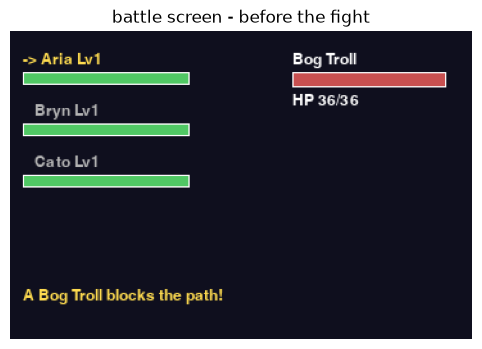

A battle begins: Aria leads the charge against Bog Troll!
Aria's attack rises by 4 for 3 turns!
Bog Troll attacks Aria for 3 damage! Aria HP: 27/30
Aria attacks Bog Troll for 8 damage! Bog Troll HP: 28/36
Bog Troll attacks Aria for 1 damage! Aria HP: 26/30
Aria attacks Bog Troll for 10 damage! Bog Troll HP: 18/36
Bog Troll attacks Aria for 2 damage! Aria HP: 24/30
Aria's attack buff wore off (back to 7)
Aria attacks Bog Troll for 4 damage! Bog Troll HP: 14/36
Bog Troll bites Aria for 2 damage and poisons them!
Aria is afflicted with poison for 3 turns!
Aria takes 2 poison damage! HP: 20/30
Aria steps back, Bryn steps up to fight!
Bog Troll attacks Bryn for 2 damage! Bryn HP: 20/22
Bryn attacks Bog Troll for 5 damage! Bog Troll HP: 9/36
Bog Troll attacks Bryn for 2 damage! Bryn HP: 18/22
Bryn attacks Bog Troll for 5 damage! Bog Troll HP: 4/36
Bog Troll attacks Bryn for 4 damage! Bryn HP: 14/22
Bryn attacks Bog Troll for 5 damage! Bog Troll HP: 0/36
Bog Troll was defeated!
Aria gains 50 

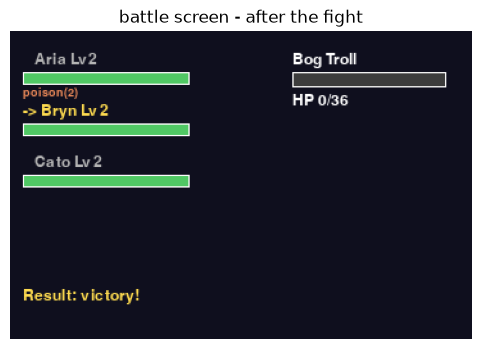


after the battle:
   Aria (Lv2, HP 35/35, ATK 9, DEF 4, XP 20/60)
-> Bryn (Lv2, HP 27/27, ATK 8, DEF 3, XP 20/60)
   Cato (Lv2, HP 21/21, ATK 11, DEF 2, XP 20/60)


In [5]:
bog_troll = Enemy("Bog Troll", hp=36, attack=5, defense=2)

# a "War Horn" buff item, already sitting in the party's bag before the fight - see the Item dataclass above
party.inventory.append(Item(name="War Horn", item_type="buff", attack_bonus=4, buff_duration=3))

# our plan: buff Aria and let her open the fight, but once the troll's poison bite starts wearing her down,
# deliberately SWITCH to Bryn (who's still at full hp) to finish the job instead of risking Aria fainting
battle_plan = [
    ("item", party.inventory[0], party.active),  # party.active is Aria right now - she gets the attack buff
    ("attack", None, None),
    ("attack", None, None),
    ("attack", None, None),
    ("switch", None, 1),  # Aria just got poisoned and is down to 20/30 hp - time to rotate Bryn in
    ("attack", None, None),
    ("attack", None, None),
    ("attack", None, None),
]

print("before the battle:")
for line in party.describe():
    print(line)

before_screen = draw_party_battle_screen(party, bog_troll, "A Bog Troll blocks the path!")
show_surface(before_screen, title="battle screen - before the fight", figsize=(6, 4))

battle_log, battle_result = run_party_battle(party, bog_troll, battle_plan)
for line in battle_log:
    print(line)
print()
print("battle result:", battle_result)

after_screen = draw_party_battle_screen(party, bog_troll, f"Result: {battle_result}!")
show_surface(after_screen, title="battle screen - after the fight", figsize=(6, 4))

print()
print("after the battle:")
for line in party.describe():
    print(line)

## a shop / economy system (recap error handling, lesson 06)
* a `Shop` just wraps a small fixed catalog of `Item`s, each with a `price`
* `buy_item()` checks the party actually has enough `gold` BEFORE completing the purchase - if they dont, we `raise` our own custom exception instead of just quietly failing or crashing weirdly (recap raising custom exceptions, lesson 06)
* we clone the catalog item with `copy.copy()` before handing it over - otherwise every purchase of "Health Potion" would hand out the SAME shared object, and using/removing one would affect all the others too

In [6]:
class NotEnoughGoldError(Exception):
    """Raised when a purchase costs more gold than the party currently has. Recap custom exceptions, lesson 06."""
    pass


class Shop:
    """A tiny shop with a fixed catalog of items for sale at fixed prices."""

    def __init__(self, name: str, catalog: list):
        self.name = name
        self.catalog = catalog  # list[Item], each with a real `price` set

    def find_item(self, item_name: str) -> Item:
        for item in self.catalog:
            if item.name == item_name:
                return item
        raise ValueError(f"{self.name} doesnt sell anything called {item_name!r}")  # a plain typo/lookup mistake


def buy_item(shop: Shop, party: Party, item_name: str) -> str:
    """Buy one copy of `item_name` from `shop` into `party`'s bag. Raises NotEnoughGoldError if they cant afford it."""
    catalog_item = shop.find_item(item_name)
    if party.gold < catalog_item.price:
        raise NotEnoughGoldError(f"{item_name} costs {catalog_item.price} gold, but the party only has {party.gold}")
    party.gold -= catalog_item.price               # pay up FIRST, only after we know they can afford it
    party.inventory.append(copy.copy(catalog_item))  # a fresh, independent clone - not the same object as the catalog entry
    return f"bought {item_name} for {catalog_item.price} gold! {party.gold} gold remaining"


village_shop = Shop(
    name="Village Shop",
    catalog=[
        Item(name="Health Potion", item_type="potion", heal_amount=15, price=10),
        Item(name="Iron Sword", item_type="weapon", attack_bonus=5, price=50),
    ],
)

print("shop catalog:", [(item.name, item.price) for item in village_shop.catalog])
print("party has", party.gold, "gold")

# a purchase we CAN afford
print(buy_item(village_shop, party, "Health Potion"))
print("inventory now:", [item.name for item in party.inventory])

# a purchase we very much CANNOT afford - the Iron Sword costs more than our remaining gold
try:
    buy_item(village_shop, party, "Iron Sword")
except NotEnoughGoldError as error:
    print("purchase rejected:", error)

print("final gold:", party.gold, "- the failed purchase correctly cost us nothing")

shop catalog: [('Health Potion', 10), ('Iron Sword', 50)]
party has 40 gold
bought Health Potion for 10 gold! 30 gold remaining
inventory now: ['Health Potion']
purchase rejected: Iron Sword costs 50 gold, but the party only has 30
final gold: 30 - the failed purchase correctly cost us nothing


## save/load persistence (using plain `json`, recap lesson 05)
* we turn the whole party's state (every member's hp/level/xp/stats/status effects, the shared gold and inventory) into one plain, JSON-friendly dict, and write it to disk with `json.dump()`
* loading builds a completely FRESH `Party` object from that file - none of the original python objects are reused, so if the loaded party matches the original, we know the round-trip genuinely preserved everything and didnt just get lucky sharing references
* recap the cleanup style from lessons 05/06/13: any file we create in a lesson gets `os.remove()`d again before the notebook ends, we never want to leave a generated save file lying around in the repo

In [7]:
SAVE_FILE_PATH = "lesson35_savegame.json"  # a plain relative filename, cleaned up again a few cells down


def save_party(party: Party, path: str) -> None:
    """Serialize the whole party's state into one JSON file."""
    data = {
        "gold": party.gold,
        "active_index": party.active_index,
        "members": [
            {
                "name": member.name, "role": member.role, "level": member.level, "xp": member.xp,
                "hp": member.hp, "max_hp": member.max_hp, "attack": member.attack, "defense": member.defense,
                "status_effects": [
                    {"name": e.name, "remaining_turns": e.remaining_turns, "potency": e.potency}
                    for e in member.status_effects
                ],
            }
            for member in party.members
        ],
        "inventory": [
            {"name": i.name, "item_type": i.item_type, "heal_amount": i.heal_amount,
             "attack_bonus": i.attack_bonus, "buff_duration": i.buff_duration, "price": i.price}
            for i in party.inventory
        ],
    }
    with open(path, "w", encoding="utf-8") as save_file:  # "with" guarantees the file gets closed even on an error
        json.dump(data, save_file, indent=2)


def load_party(path: str) -> Party:
    """Rebuild a completely FRESH Party (fresh PartyMember/Item objects too) from a save file written by save_party()."""
    with open(path, "r", encoding="utf-8") as save_file:
        data = json.load(save_file)

    loaded_members = []
    for member_data in data["members"]:
        member = PartyMember(member_data["name"], member_data["role"],
                              hp=member_data["max_hp"], attack=member_data["attack"], defense=member_data["defense"])
        member.hp = member_data["hp"]        # override AFTER construction - construction always starts at full hp
        member.level = member_data["level"]
        member.xp = member_data["xp"]
        member.status_effects = [StatusEffect(**effect_data) for effect_data in member_data["status_effects"]]
        loaded_members.append(member)

    fresh_party = Party(members=loaded_members, gold=data["gold"])
    fresh_party.active_index = data["active_index"]
    fresh_party.inventory = [Item(**item_data) for item_data in data["inventory"]]
    return fresh_party


print("state BEFORE saving:")
for line in party.describe():
    print(" ", line)
print(" gold:", party.gold, "| inventory:", [item.name for item in party.inventory])

save_party(party, SAVE_FILE_PATH)
print(f"\nsaved to {SAVE_FILE_PATH!r}, file exists on disk?", os.path.exists(SAVE_FILE_PATH))

loaded_party = load_party(SAVE_FILE_PATH)  # a BRAND NEW Party object, built purely from what we just wrote to disk
print("\nstate AFTER loading into a fresh Party object:")
for line in loaded_party.describe():
    print(" ", line)
print(" gold:", loaded_party.gold, "| inventory:", [item.name for item in loaded_party.inventory])

# prove the round-trip really preserved everything, by comparing the two independent objects field by field
names_match = [m.name for m in party.members] == [m.name for m in loaded_party.members]
hp_match = [m.hp for m in party.members] == [m.hp for m in loaded_party.members]
level_match = [m.level for m in party.members] == [m.level for m in loaded_party.members]
gold_match = party.gold == loaded_party.gold
inventory_match = [i.name for i in party.inventory] == [i.name for i in loaded_party.inventory]
print("\nnames match?", names_match, "| hp match?", hp_match, "| level match?", level_match,
      "| gold match?", gold_match, "| inventory match?", inventory_match)
print("are these literally the same python objects?", party is loaded_party, "(they must NOT be - its a fresh load)")

os.remove(SAVE_FILE_PATH)  # cleanup - never leave a generated save file lying around in the repo
print("\ncleaned up, save file still exists?", os.path.exists(SAVE_FILE_PATH))

state BEFORE saving:
     Aria (Lv2, HP 35/35, ATK 9, DEF 4, XP 20/60)
  -> Bryn (Lv2, HP 27/27, ATK 8, DEF 3, XP 20/60)
     Cato (Lv2, HP 21/21, ATK 11, DEF 2, XP 20/60)
 gold: 30 | inventory: ['Health Potion']

saved to 'lesson35_savegame.json', file exists on disk? True

state AFTER loading into a fresh Party object:
     Aria (Lv2, HP 35/35, ATK 9, DEF 4, XP 20/60)
  -> Bryn (Lv2, HP 27/27, ATK 8, DEF 3, XP 20/60)
     Cato (Lv2, HP 21/21, ATK 11, DEF 2, XP 20/60)
 gold: 30 | inventory: ['Health Potion']

names match? True | hp match? True | level match? True | gold match? True | inventory match? True
are these literally the same python objects? False (they must NOT be - its a fresh load)

cleaned up, save file still exists? False


## multiple connected map areas (recap the tile-grid style from lesson 31)
* a "real" RPG world is basically never just ONE map - it's lots of small maps (a town, a house, a dungeon floor, ...) connected by WARP POINTS: step onto a special tile (a door, stairs, a cave entrance, ...) and you get moved to a specific spot on a DIFFERENT map
* we represent each map exactly like lesson 31 did - a list of strings, one character per tile - and add one new tile type, `"D"` (a door), which is walkable AND doubles as a warp trigger
* `WARPS` is just a lookup dict: `(map_name, x, y) -> (target_map_name, target_x, target_y)` - landing on a door tile looks itself up in this dict and teleports the player accordingly. notice the landing spots are NOT themselves door tiles, otherwise stepping through a door would immediately trigger warping straight back!

right: moved right to (2, 1) on 'town'
right: moved right to (3, 1) on 'town'
right: moved right to (4, 1) on 'town'
right: moved right to (5, 1) on 'town'
 down: moved down to (5, 2) on 'town'
 down: moved down to (5, 3) on 'town'
 down: moved down to (5, 4) on 'town'


 down: moved down onto a door and warped from 'town' to 'house' at (4, 3)

player ended up on map: house at position: (4, 3)


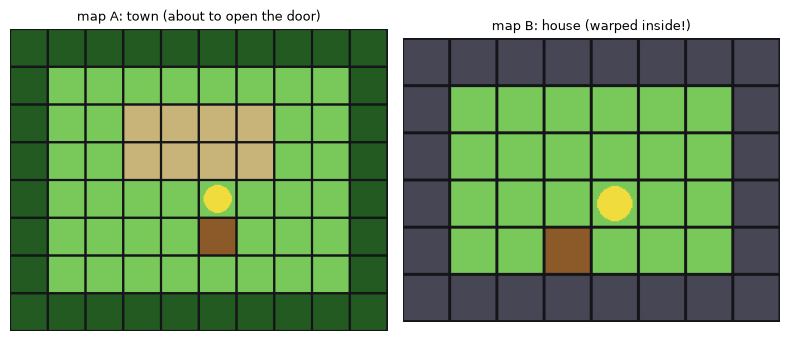

In [8]:
TILE_SIZE = 32  # each tile is a 32x32 pixel square, same convention as lesson 31

TILE_COLORS = {
    "T": (34, 90, 34),     # tree/wall (outdoors) - dark green, blocks movement
    "#": (70, 70, 85),     # wall (indoors) - grey, blocks movement
    ".": (120, 200, 90),   # grass/floor - walkable
    ",": (200, 180, 120),  # stone path - walkable
    "D": (140, 90, 40),    # a door/warp tile - walkable, AND triggers a map transition when stepped on
}
WALKABLE_TILES = {".", ",", "D"}  # everything except T and # can be walked on

TOWN_MAP = [
    "TTTTTTTTTT",
    "T........T",
    "T..,,,,..T",
    "T..,,,,..T",
    "T........T",
    "T....D...T",   # the door at (5, 5) leads INTO the house
    "T........T",
    "TTTTTTTTTT",
]

HOUSE_MAP = [
    "########",
    "#......#",
    "#......#",
    "#......#",
    "#..D...#",   # the door at (3, 4) leads back OUT to the town
    "########",
]

MAPS = {"town": TOWN_MAP, "house": HOUSE_MAP}

# warp lookup: (current map, x, y) -> (target map, entry x, entry y). note the entry points are plain floor tiles,
# NOT door tiles themselves - landing on another door would immediately warp you again, an infinite ping-pong!
WARPS = {
    ("town", 5, 5): ("house", 4, 3),
    ("house", 3, 4): ("town", 5, 6),
}

DIRECTION_VECTORS = {"up": (0, -1), "down": (0, 1), "left": (-1, 0), "right": (1, 0)}  # recap lesson 31


class WorldPlayer:
    """A player that can walk around, tracking WHICH map its on as well as its grid position on that map."""

    def __init__(self, map_name: str, x: int, y: int):
        self.map_name = map_name
        self.x = x
        self.y = y

    def move(self, direction: str) -> str:
        """Move one tile, respecting wall collision, and automatically warp if we land on a door tile."""
        delta_x, delta_y = DIRECTION_VECTORS[direction]
        target_x, target_y = self.x + delta_x, self.y + delta_y
        current_map = MAPS[self.map_name]

        if target_y < 0 or target_y >= len(current_map) or target_x < 0 or target_x >= len(current_map[target_y]):
            return "blocked (off the map)"  # a defensive bounds check, shouldnt normally trigger on our maps
        tile_char = current_map[target_y][target_x]
        if tile_char not in WALKABLE_TILES:
            return f"blocked by a {'wall' if tile_char in ('T', '#') else tile_char} tile"

        self.x, self.y = target_x, target_y  # the move itself - only happens once we know the tile is walkable

        warp_key = (self.map_name, self.x, self.y)
        if warp_key in WARPS:  # did we just step onto a door? then warp to the other side right away
            target_map, entry_x, entry_y = WARPS[warp_key]
            old_map = self.map_name
            self.map_name, self.x, self.y = target_map, entry_x, entry_y
            return f"moved {direction} onto a door and warped from {old_map!r} to {target_map!r} at ({entry_x}, {entry_y})"
        return f"moved {direction} to ({self.x}, {self.y}) on {self.map_name!r}"


def render_map(world_map: list, player: WorldPlayer = None, highlight_player: bool = True):
    """Draw one whole tile map (and the player, if theyre currently standing on it) onto a fresh Surface."""
    cols, rows = len(world_map[0]), len(world_map)
    surface = pygame.Surface((cols * TILE_SIZE, rows * TILE_SIZE))
    for row_index, row in enumerate(world_map):
        for col_index, tile_char in enumerate(row):
            tile_rect = (col_index * TILE_SIZE, row_index * TILE_SIZE, TILE_SIZE, TILE_SIZE)
            pygame.draw.rect(surface, TILE_COLORS[tile_char], tile_rect)
            pygame.draw.rect(surface, (20, 20, 25), tile_rect, 1)  # thin grid lines so individual tiles are visible
    if player is not None and highlight_player:
        center = (player.x * TILE_SIZE + TILE_SIZE // 2, player.y * TILE_SIZE + TILE_SIZE // 2)
        pygame.draw.circle(surface, (240, 220, 60), center, TILE_SIZE // 2 - 4)  # a yellow circle for the player
    return surface


# our scripted walk: start in the town, march over to the door, and watch the warp happen automatically
world_player = WorldPlayer(map_name="town", x=1, y=1)
walk_script = ["right", "right", "right", "right", "down", "down", "down", "down"]  # (1,1) -> (5,1) -> (5,5), the door!

town_before_snapshot = None
for step in walk_script:
    result = world_player.move(step)
    print(f"{step:>5s}: {result}")
    if world_player.map_name == "town" and (world_player.x, world_player.y) == (5, 4):
        # grab a snapshot right before the final step that actually walks onto the door, so we can SEE map A first
        town_before_snapshot = pygame.surfarray.array3d(render_map(TOWN_MAP, world_player)).swapaxes(0, 1).copy()

house_after_snapshot = pygame.surfarray.array3d(render_map(HOUSE_MAP, world_player)).swapaxes(0, 1).copy()

print("\nplayer ended up on map:", world_player.map_name, "at position:", (world_player.x, world_player.y))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(town_before_snapshot)
axes[0].set_title("map A: town (about to open the door)", fontsize=9)
axes[0].axis("off")
axes[1].imshow(house_after_snapshot)
axes[1].set_title("map B: house (warped inside!)", fontsize=9)
axes[1].axis("off")
plt.tight_layout()
plt.show()

## quick comparison to other languages
* leveling/XP and status-effect systems are so universal across the whole RPG genre that a hugely popular way to implement them in BIGGER engines is an **ECS (entity-component-system) architecture** - Unity DOTS and plenty of custom C++ engines work this way. instead of one giant inheritance hierarchy (our `Character` -> `PartyMember`/`Enemy` chain), you attach small independent COMPONENTS like `Health`, `StatusEffects`, `Inventory`, `Leveling` to any entity that needs them - a chest can have an `Inventory` component with no `Health` at all, a wall trap can have a `StatusEffects`-inflicting component with no `Inventory`, and so on. more flexible at scale, but noticeably more machinery to set up than the plain classes we used here
* multi-area maps connected by warp points are EXACTLY how RPG Maker, Godot (separate Scene files, loaded on transition) and classic Game Boy-era games structure their whole world - "map + door tile + target map/position" is the same idea in every single one of them, just with a fancier map editor instead of our plain list-of-strings
* a shop/economy system backed by a persistent save file is standard across the genre in EVERY engine - Unity and Godot projects typically save to JSON or a small binary format, which is conceptually identical to what we just did with plain `json`: turn the game state into a serializable structure, write it, and rebuild fresh objects from it on load

## Exercises
1. add a `"regen"` status effect to `Character.tick_status_effects()` that HEALS a small amount each turn instead of damaging (the opposite of poison) - attach one to a character and show it healing over a couple of turns
2. add a THIRD party member to a fresh `Party` and write a scripted mini-battle where you deliberately `switch_active()` to them partway through
3. add a second item to `village_shop`'s catalog and demonstrate buying BOTH items in a row, when the party can afford both
4. add a third connected map (e.g. a small "cave" reachable from the house) with its own warp point, and script a walk that visits all three maps in one trip

In [9]:
# TODO: solve exercise 1 here (a healing "regen" status effect)


# TODO: solve exercise 2 here (a third party member + a mid-battle switch to them)


# TODO: solve exercise 3 here (a second shop item, buy both if affordable)


# TODO: solve exercise 4 here (a third connected map with its own warp point)

### sample solutions
* try the exercises above yourself first, only look here if you are stuck or want to compare your approach

In [10]:
# sample solution 1 - a "regen" status effect that heals instead of damages
def tick_status_effects_with_regen(character: Character) -> list:
    """A drop-in replacement for Character.tick_status_effects() that also understands "regen"."""
    log = []
    still_active = []
    for effect in character.status_effects:
        if effect.name == "poison":
            character.take_damage(effect.potency)
            log.append(f"{character.name} takes {effect.potency} poison damage! HP: {character.hp}/{character.max_hp}")
        elif effect.name == "regen":
            healed = character.heal(effect.potency)  # heal() already clamps at max_hp, recap earlier in this lesson
            log.append(f"{character.name} regenerates {healed} HP! HP: {character.hp}/{character.max_hp}")
        effect.remaining_turns -= 1
        if effect.remaining_turns > 0:
            still_active.append(effect)
        elif effect.name == "attack_buff":
            character.attack -= effect.potency
    character.status_effects = still_active
    return log


regen_demo = PartyMember("Dara", role="Healer", hp=25, attack=4, defense=2)
regen_demo.hp = 10  # hurt them first, so we can actually SEE the regen effect working
regen_demo.status_effects.append(StatusEffect(name="regen", remaining_turns=3, potency=4))
for turn in range(3):
    for line in tick_status_effects_with_regen(regen_demo):
        print(line)


# sample solution 2 - a third party member and a mid-battle switch to them
exercise_party = Party(members=[
    PartyMember("Finn", role="Warrior", hp=28, attack=6, defense=3),
    PartyMember("Sable", role="Rogue", hp=20, attack=8, defense=1),
    PartyMember("Wren", role="Cleric", hp=24, attack=5, defense=2),  # our THIRD member, joining the party
], gold=0)
exercise_enemy = Enemy("Giant Rat", hp=14, attack=3, defense=1)

print("\nstarting active member:", exercise_party.active.name)
exercise_log, exercise_result = run_party_battle(exercise_party, exercise_enemy, [("attack", None, None)])
print("battle 1 result:", exercise_result, "- active is still", exercise_party.active.name)

switch_message = exercise_party.switch_active(2)  # deliberately switch to Wren (index 2), our third member
print(switch_message)
print("active member is now:", exercise_party.active.name)


# sample solution 3 - a second shop item, buying both when affordable
village_shop.catalog.append(Item(name="Leather Armor", item_type="weapon", attack_bonus=0, price=8))  # cheap, so we can afford it
rich_party = Party(members=[PartyMember("Payer", role="Warrior", hp=20, attack=5, defense=2)], gold=100)
for item_name in ["Health Potion", "Leather Armor"]:
    print(buy_item(village_shop, rich_party, item_name))
print("bought both! inventory:", [item.name for item in rich_party.inventory], "| gold left:", rich_party.gold)


# sample solution 4 - a third connected map with its own warp point
CAVE_MAP = [
    "######",
    "#....#",
    "#....#",
    "######",
]
MAPS["cave"] = CAVE_MAP  # register it alongside "town" and "house" so render_map()/WorldPlayer can reach it

# add a torch "D" door at the bottom-right of the house leading to the cave, and one back from the cave
HOUSE_MAP_WITH_CAVE_DOOR = HOUSE_MAP.copy()
HOUSE_MAP_WITH_CAVE_DOOR[2] = "#.....D#"  # a second door in the house, at (6, 2), leading down into the cave
MAPS["house"] = HOUSE_MAP_WITH_CAVE_DOOR
WARPS[("house", 6, 2)] = ("cave", 1, 1)
WARPS[("cave", 1, 1)] = ("house", 5, 2)  # and a way back out again

trip_player = WorldPlayer(map_name="town", x=1, y=1)
trip_route = ["right", "right", "right", "right", "down", "down", "down", "down",  # town -> house
              "right", "right"]  # house (4,3) -> (6,3)? lets step towards our new cave door at (6,2) instead:
trip_route = ["right", "right", "right", "right", "down", "down", "down", "down",  # town(1,1) -> house(4,3) via door
              "up", "right", "right"]  # house(4,3) -> (4,2) -> (5,2) -> (6,2), the new cave door
for step in trip_route:
    print(step, "->", trip_player.move(step))
print("visited town, house AND", trip_player.map_name, "- a full 3-map trip!")

Dara regenerates 4 HP! HP: 14/25
Dara regenerates 4 HP! HP: 18/25
Dara regenerates 4 HP! HP: 22/25

starting active member: Finn
battle 1 result: victory - active is still Finn
Finn steps back, Wren steps up to fight!
active member is now: Wren
bought Health Potion for 10 gold! 90 gold remaining
bought Leather Armor for 8 gold! 82 gold remaining
bought both! inventory: ['Health Potion', 'Leather Armor'] | gold left: 82
right -> moved right to (2, 1) on 'town'
right -> moved right to (3, 1) on 'town'
right -> moved right to (4, 1) on 'town'
right -> moved right to (5, 1) on 'town'
down -> moved down to (5, 2) on 'town'
down -> moved down to (5, 3) on 'town'
down -> moved down to (5, 4) on 'town'
down -> moved down onto a door and warped from 'town' to 'house' at (4, 3)
up -> moved up to (4, 2) on 'house'
right -> moved right to (5, 2) on 'house'
right -> moved right onto a door and warped from 'house' to 'cave' at (1, 1)
visited town, house AND cave - a full 3-map trip!


* congratulation you finished this lesson

## what we learned
* leveling and XP: a `Character.gain_xp()` that loops (not just an `if`!) so a big reward can trigger several level-ups at once, and `level_up()` permanently boosting `max_hp`/`attack`/`defense` plus a full heal
* status effects as a small `StatusEffect` dataclass processed once per turn by `tick_status_effects()` - poison damage that ticks down and expires, and a temporary attack buff that applies immediately and reverts itself automatically once its turns run out
* a multi-member `Party` (built from a shared `Character` base, recap inheritance) with exactly one `active` member fighting at a time, and `switch_active()` to swap who that is - including an automatic "switch the fragile one out" rule inside the battle loop itself
* a `Shop`/economy system with fixed-price items and a `gold` currency, using a custom `NotEnoughGoldError` exception (recap raising your own exceptions, lesson 06) so an unaffordable purchase fails cleanly instead of crashing or silently doing nothing
* save/load persistence with plain `json`: serializing the whole party into one dict, writing it to disk, and rebuilding a completely FRESH `Party` object from it to prove the round-trip really preserves everything - then cleaning the file up with `os.remove()` so nothing gets left behind
* multiple connected tile maps (recap lesson 31's list-of-strings style) linked by warp/door tiles and a `(map, x, y) -> (map, x, y)` lookup dict, the same basic trick every tile-based RPG engine (RPG Maker, Godot, classic Game Boy games) uses to stitch a whole world together out of small pieces
* how this stack of systems maps onto bigger engines: ECS architectures for components like Health/Inventory/StatusEffects, scene-based map transitions, and JSON/binary save files - different tools, same underlying ideas